# 🔬 HematoVision: Blood Cell Classification using CNN
**Runtime → Change runtime type → GPU (T4)**

## Step 1: Install Kaggle & Import Libraries

In [1]:
!pip install -q kaggle

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Download Dataset from Kaggle

In [3]:
# Enter your Kaggle credentials
# Get them from: https://www.kaggle.com/settings -> Create New Token

os.environ['KAGGLE_USERNAME'] = input('Enter Kaggle Username: ')
os.environ['KAGGLE_KEY'] = input('Enter Kaggle API Key: ')

Enter Kaggle Username: demo61161
Enter Kaggle API Key: KGAT_2224902fc8c238ba554bc0b8dee15043


In [4]:
# Download and extract dataset
!kaggle datasets download -d paultimothymooney/blood-cells
!unzip -q blood-cells.zip -d blood_cells_data
print('\n✅ Dataset downloaded!')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:00<00:00, 138MB/s] 


✅ Dataset downloaded!


In [5]:
# Find the TRAIN folder path
base = 'blood_cells_data'
for root, dirs, files in os.walk(base):
    if 'TRAIN' in dirs:
        TRAIN_DIR = os.path.join(root, 'TRAIN')
        TEST_DIR = os.path.join(root, 'TEST')
        break

print('Train:', TRAIN_DIR)
print('Test:', TEST_DIR)
print('Classes:', sorted(os.listdir(TRAIN_DIR)))

Train: blood_cells_data/dataset2-master/dataset2-master/images/TRAIN
Test: blood_cells_data/dataset2-master/dataset2-master/images/TEST
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## Step 3: Explore the Dataset

In [6]:
# Count images per class
classes = sorted(os.listdir(TRAIN_DIR))
for cls in classes:
    path = os.path.join(TRAIN_DIR, cls)
    print(f'{cls}: {len(os.listdir(path))} images')

EOSINOPHIL: 2497 images
LYMPHOCYTE: 2483 images
MONOCYTE: 2478 images
NEUTROPHIL: 2499 images


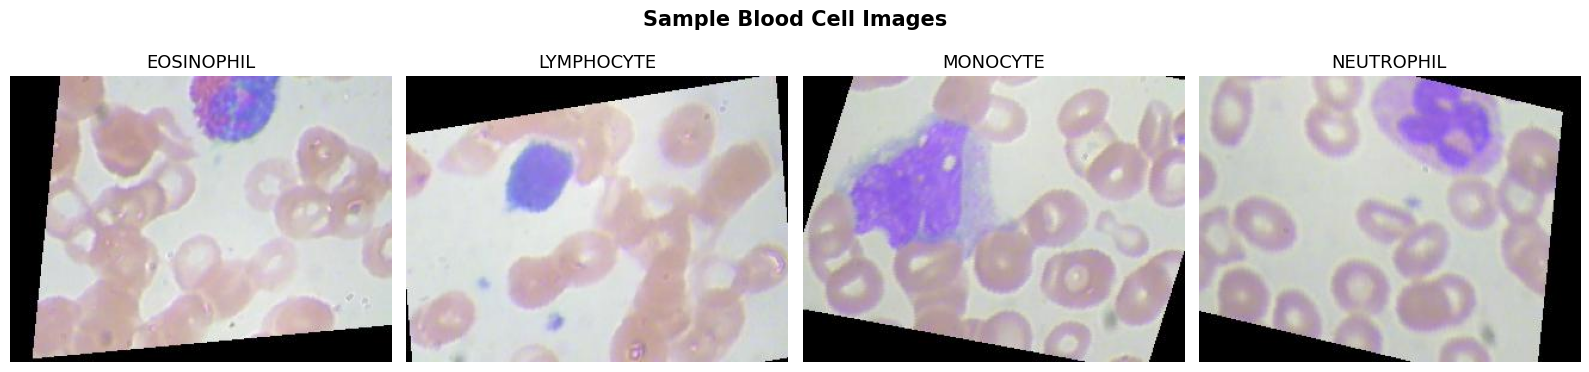

In [7]:
# Show sample images
import cv2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    path = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(path)[0]
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13)
    axes[i].axis('off')
plt.suptitle('Sample Blood Cell Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Updated Data Augmentation: Removed vertical_flip
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('\nClass mapping:', train_generator.class_indices)

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.

Class mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


## Step 5: Build Custom CNN Model

In [9]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Classifier: Reduced to 256 for stability
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,700 (50.50 MB)

 Trainable params: 13,236,228 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [10]:
# Learning rate reduced to 0.0001 for better stability
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('✅ Model re-optimized with lower learning rate!')

✅ Model re-optimized with lower learning rate!


## Step 6: Train the Model

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Optimized callbacks
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)

EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[lr_reducer, early_stop]
)
print('\n✅ Training complete!')

Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 138s 507ms/step - accuracy: 0.4104 - loss: 1.6524 - val_accuracy: 0.2509 - val_loss: 2.8880 - learning_rate: 1.0000e-04
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 120s 482ms/step - accuracy: 0.6265 - loss: 0.9674 - val_accuracy: 0.4942 - val_loss: 1.3370 - learning_rate: 1.0000e-04
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 121s 484ms/step - accuracy: 0.7693 - loss: 0.5941 - val_accuracy: 0.7340 - val_loss: 0.7216 - learning_rate: 1.0000e-04
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 121s 485ms/step - accuracy: 0.8463 - loss: 0.4045 - val_accuracy: 0.5802 - val_loss: 1.4295 - learning_rate: 1.0000e-04
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8795 - loss: 0.3050
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
249/249 ━━━━━━━━━━━━━━━━━━━━ 120s 483ms/step - accuracy: 0.8818 - loss: 0.2990 - val_accuracy: 0.6144 - val_loss: 1.4384 - learning_rate: 1.0000e-04
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 121s 4

## Step 7: Accuracy & Loss Graphs

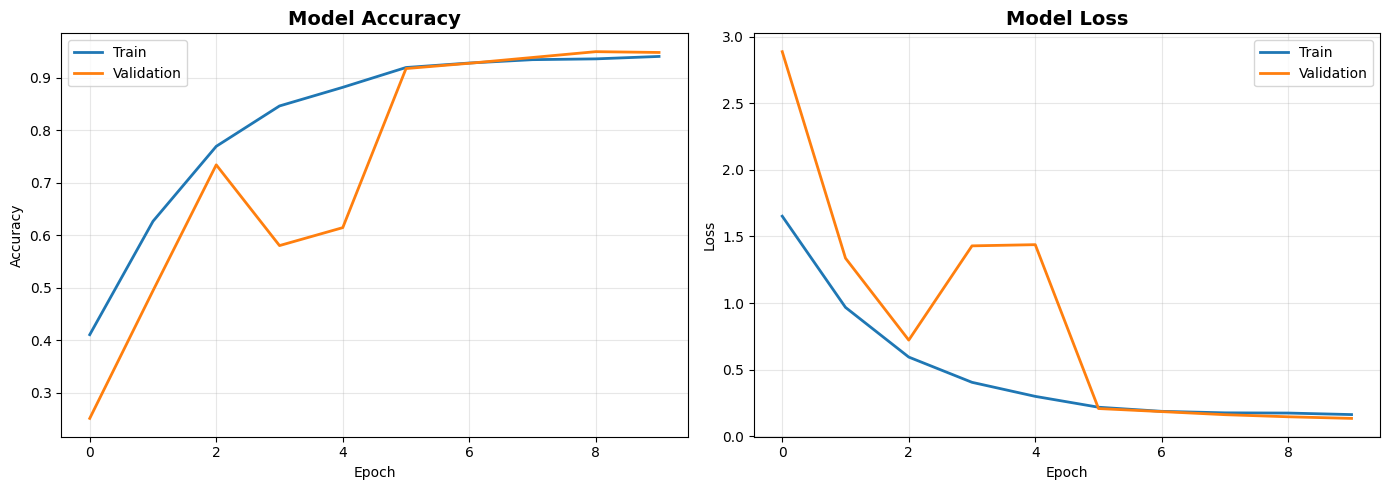

Final Train Accuracy: 0.9406
Final Val Accuracy:   0.9482


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Accuracy: {history.history["accuracy"][-1]:.4f}')
print(f'Final Val Accuracy:   {history.history["val_accuracy"][-1]:.4f}')

## Step 8: Evaluate on Test Set

In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss:     {test_loss:.4f}')

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.7877 - loss: 0.6520

Test Accuracy: 0.7877 (78.77%)
Test Loss:     0.6520


## Step 9: Confusion Matrix

78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step


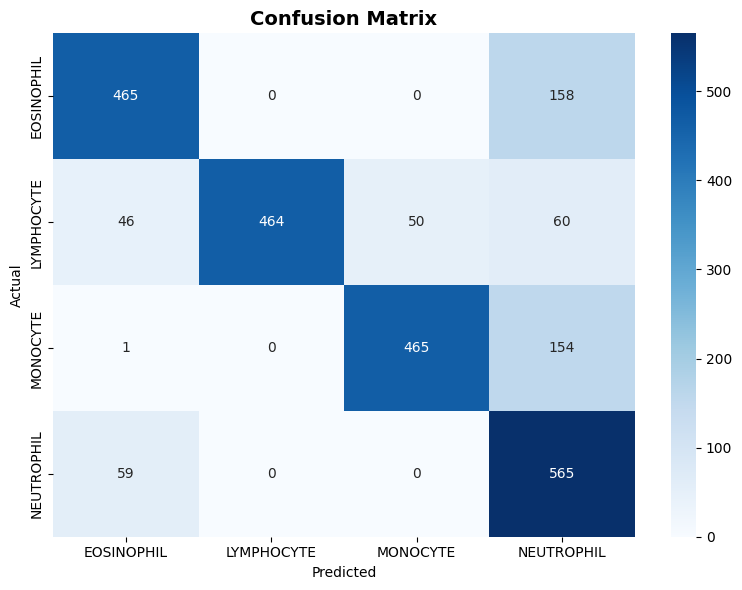

In [14]:
# Get predictions
test_generator.reset()
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 10: Classification Report

In [15]:
print('Classification Report:')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.81      0.75      0.78       623
  LYMPHOCYTE       1.00      0.75      0.86       620
    MONOCYTE       0.90      0.75      0.82       620
  NEUTROPHIL       0.60      0.91      0.72       624

    accuracy                           0.79      2487
   macro avg       0.83      0.79      0.79      2487
weighted avg       0.83      0.79      0.79      2487



## Step 11: Save Model

In [16]:
model.save('Blood_Cell.h5')
size = os.path.getsize('Blood_Cell.h5') / (1024*1024)
print(f'✅ Model saved as Blood_Cell.h5 ({size:.2f} MB)')

✅ Model saved as Blood_Cell.h5 (151.58 MB)


## Step 12: Download Model

In [17]:
from google.colab import files
files.download('Blood_Cell.h5')
print('✅ Download started! Check your browser downloads.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your browser downloads.


---
## ✅ Done!
Place `Blood_Cell.h5` in your HematoVision folder and run `python app.py`